# Customer Segmentation using K-Means Clustering

This notebook implements an unsupervised machine learning pipeline to segment retail customers based on demographic and purchasing behavior data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib

## Load and Inspect Dataset

We load the customer dataset and inspect its structure, checking dimensions, column data types, missing values, and descriptive statistics.

In [2]:
df = pd.read_csv("../data/Mall_Customers.csv")
print(df.shape)
print(df.info())
print(df.describe())

(200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.0

## Exploratory Data Analysis (EDA)

We visualize the distribution of individual features and run pairwise scatter plots to identify natural groupings before clustering.

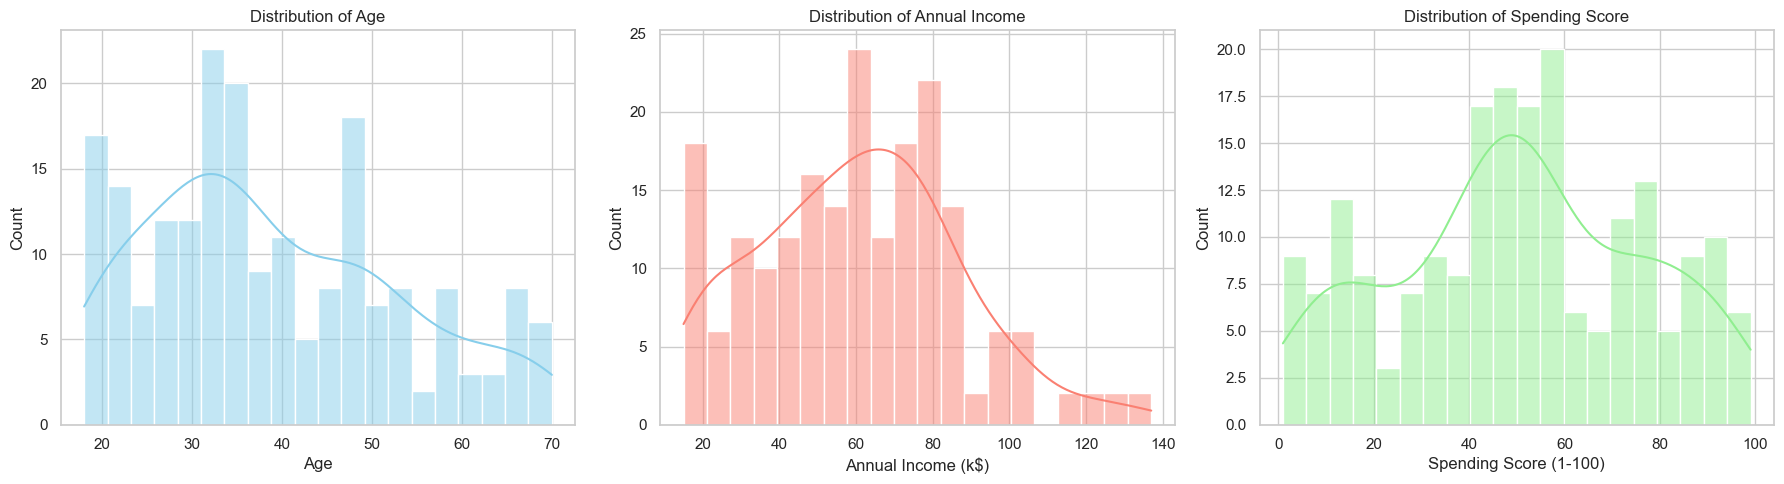

In [3]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df["Age"], bins=20, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Distribution of Age")
sns.histplot(df["Annual Income (k$)"], bins=20, kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Distribution of Annual Income")
sns.histplot(df["Spending Score (1-100)"], bins=20, kde=True, ax=axes[2], color="lightgreen")
axes[2].set_title("Distribution of Spending Score")
plt.tight_layout()
plt.savefig("eda_distributions.png")
plt.show()

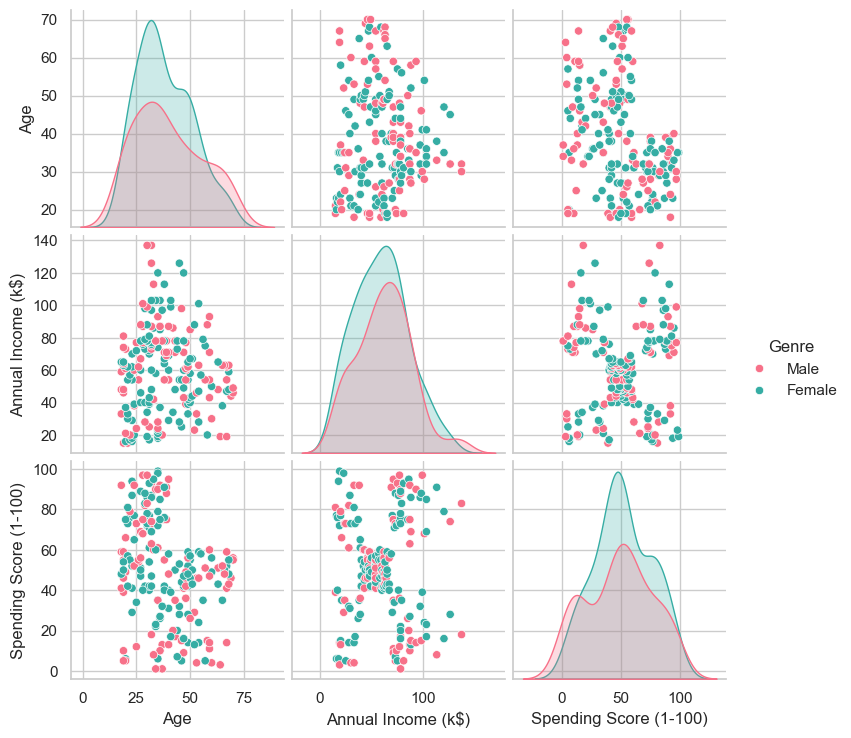

In [4]:
sns.pairplot(df.drop(columns=["CustomerID"]), hue="Genre", palette="husl")
plt.savefig("eda_pairplot.png")
plt.show()

## Feature Scaling

Since K-Means is a distance-based clustering algorithm, feature scaling is necessary to prevent variables with larger scales from dominating the distance calculations.

In [5]:
features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[features])
df_scaled = pd.DataFrame(scaled_features, columns=features)
print(df_scaled.head())

        Age  Annual Income (k$)  Spending Score (1-100)
0 -1.424569           -1.738999               -0.434801
1 -1.281035           -1.738999                1.195704
2 -1.352802           -1.700830               -1.715913
3 -1.137502           -1.700830                1.040418
4 -0.563369           -1.662660               -0.395980


## Determining Optimal Clusters (k)

We fit K-Means clustering across a range of k values from 2 to 10 and compute both inertia and silhouette scores.

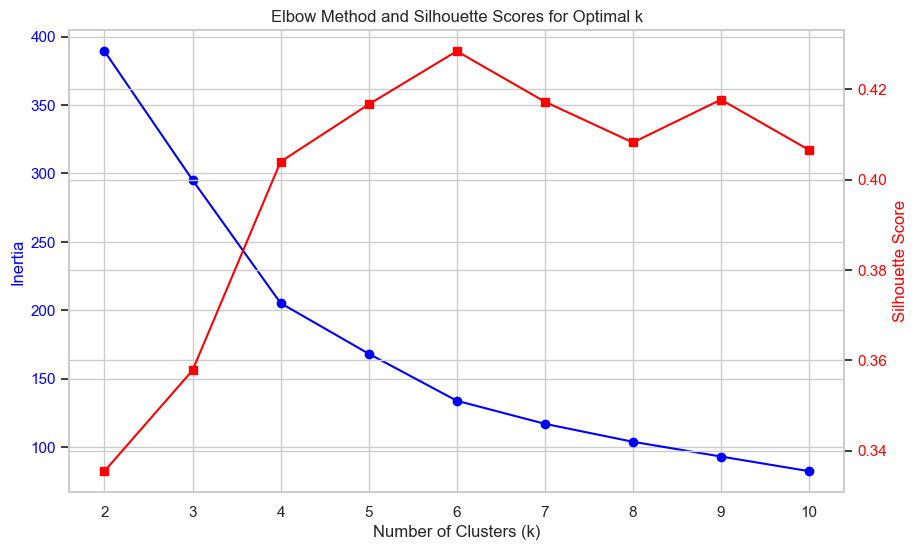

k = 2: Inertia = 389.39, Silhouette Score = 0.3355
k = 3: Inertia = 295.21, Silhouette Score = 0.3578
k = 4: Inertia = 205.23, Silhouette Score = 0.4040
k = 5: Inertia = 168.25, Silhouette Score = 0.4166
k = 6: Inertia = 133.87, Silhouette Score = 0.4284
k = 7: Inertia = 117.01, Silhouette Score = 0.4172
k = 8: Inertia = 103.87, Silhouette Score = 0.4082
k = 9: Inertia = 93.09, Silhouette Score = 0.4177
k = 10: Inertia = 82.39, Silhouette Score = 0.4066


In [6]:
inertia_values = []
silhouette_scores = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia_values.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(scaled_features, kmeans.labels_))

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(k_range, inertia_values, marker="o", color="blue")
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_scores, marker="s", color="red")
ax2.set_ylabel("Silhouette Score", color="red")
ax2.tick_params(axis="y", labelcolor="red")

plt.title("Elbow Method and Silhouette Scores for Optimal k")
plt.savefig("elbow_plot.png")
plt.show()

for k, inertia, score in zip(k_range, inertia_values, silhouette_scores):
    print(f"k = {k}: Inertia = {inertia:.2f}, Silhouette Score = {score:.4f}")

## Fit Final K-Means Model

Based on the elbow plot and silhouette analysis, k = 6 is selected. The inertia curve shows a clear inflection around k = 5-6, and the silhouette score peaks at k = 6 (0.4284), confirming that six clusters provide the most cohesive and well-separated grouping.

In [7]:
optimal_k = 6
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(scaled_features)
print(df["Cluster"].value_counts())

Cluster
0    45
1    39
3    39
2    33
4    23
5    21
Name: count, dtype: int64


## Cluster Visualization

We visualize the clusters in a 3D scatter plot and a 2D income vs spending plot to see the relationships across Age, Annual Income, and Spending Score.

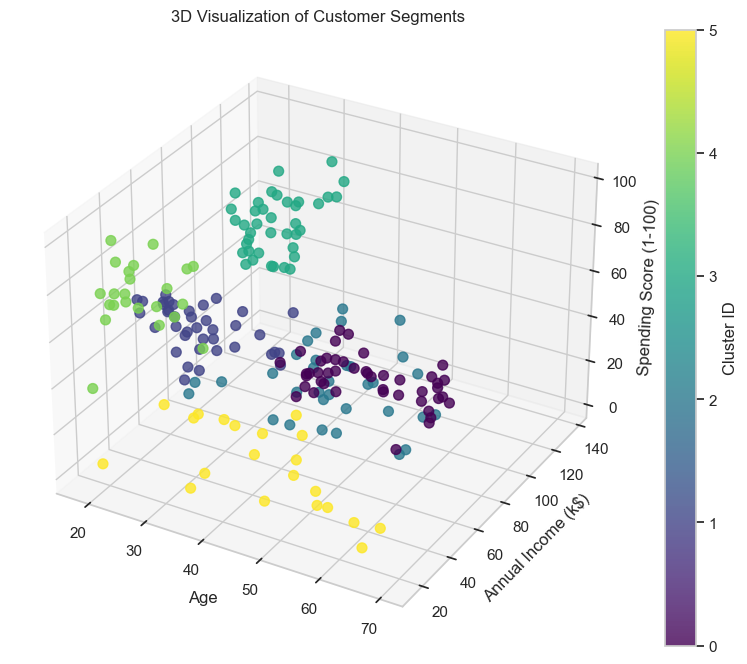

In [8]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
scatter = ax.scatter(
    df["Age"],
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis",
    s=50,
    alpha=0.8
)
ax.set_xlabel("Age")
ax.set_ylabel("Annual Income (k$)")
ax.set_zlabel("Spending Score (1-100)")
ax.set_title("3D Visualization of Customer Segments")
fig.colorbar(scatter, ax=ax, label="Cluster ID")
plt.savefig("cluster_3d_plot.png")
plt.show()

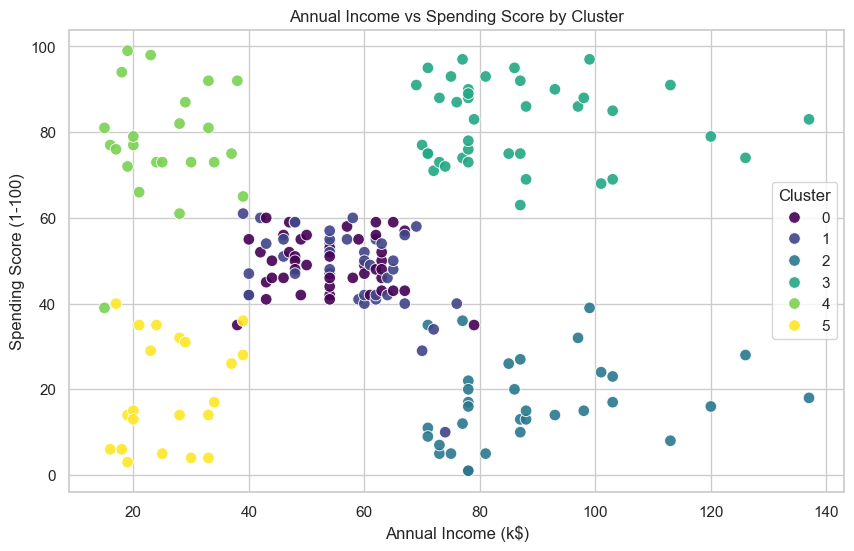

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="viridis",
    s=70,
    alpha=0.9
)
plt.title("Annual Income vs Spending Score by Cluster")
plt.savefig("cluster_2d_plot.png")
plt.show()

## Cluster Profiling and Marketing Personas

We compute the mean values of each feature within each cluster and profile the customer segments to define marketing strategies.

In [10]:
profile = df.groupby("Cluster")[features].mean()
profile["Size"] = df.groupby("Cluster").size()
print(profile)

               Age  Annual Income (k$)  Spending Score (1-100)  Size
Cluster                                                             
0        56.333333           54.266667               49.066667    45
1        26.794872           57.102564               48.128205    39
2        41.939394           88.939394               16.969697    33
3        32.692308           86.538462               82.128205    39
4        25.000000           25.260870               77.608696    23
5        45.523810           26.285714               19.380952    21


### Persona Descriptions

| Segment | Name | Profile | Marketing Action |
|---|---|---|---|
| 0 | Traditionalists | Older customers with moderate incomes and moderate spending habits | Target with practical, reliable products and loyalty program incentives |
| 1 | Young Moderate Spenders | Younger customers with moderate incomes and moderate spending habits | Engage through social media marketing and subscription-based service offers |
| 2 | Affluent Conservatives | Middle-aged customers with high incomes but low spending scores | Target with high-end premium goods and exclusive VIP invitations |
| 3 | High-Value Trendsetters | Young-to-middle-aged customers with high incomes and high spending scores | Target with luxury items, new arrivals, and personal shopper services |
| 4 | Spender Apprentices | Young customers with low incomes but high spending scores | Promote flash sales, student discounts, and buy-now-pay-later options |
| 5 | Budget Conscious | Middle-aged to older customers with low incomes and low spending scores | Focus on budget friendly products and clearance sales |

## Save Outputs

We save the cluster-labeled customer dataset as a CSV file. We also bundle the trained StandardScaler and KMeans model into a single joblib file for consistent feature scaling and predictions in production.

In [11]:
df.to_csv("../data/customer_segments.csv", index=False)
model_bundle = {
    "scaler": scaler,
    "model": kmeans
}
joblib.dump(model_bundle, "../models/customer_segmentation_model.joblib")
print("Saved artifacts successfully.")

Saved artifacts successfully.
